# Platonic Solid POVM Vertices and Verification -- Walkthrough

A companion walkthrough for Appendix E of the thesis (*POVM Vertices and Verification*), and
an **independent verifier** of `code/povm_properties.py`. The production code does two jobs in
one file: it builds the POVMs and verifies their properties, but it also emits LaTeX table
fragments for the appendix. This notebook reimplements *only* the math, from scratch, with
markdown prose mirroring Section 2.5 and Appendix E of the thesis.

We cover, for each of the five Platonic solids inscribed on the Bloch sphere:

1. **Vertex constructions** + sanity checks (unit norm, zero sum) + a 3D visualization.
2. **POVM elements** $E_k = (1/V)(\mathbf{I} + \hat n_k \cdot \vec\sigma)$ + completeness.
3. **Informational completeness** -- two symbolic checks, the second strictly stronger:
   - vec'd-effect rank in the Pauli basis,
   - the second-moment identity $\frac{1}{V}\sum_k |\psi_k\rangle\!\langle\psi_k|^{\otimes 2} = \frac{1}{6}(\mathbf{I}_4 + \mathrm{SWAP}_{12})$.
4. **Complex projective design strength** via frame potentials and Welch-bound saturation.
5. **Spherical design strength** via discrete-vs-continuous moment tensors.
6. **Closed-form pairwise overlap multisets**.
7. **Dual alignment and the covariance copy** -- every tabulated dual pair is dual-*aligned*,
   and conjugation by $\Phi$ (but not $\Phi^\star$) permutes the icosahedral pair's effects:
   the tabulated family belongs to the atlas copy $\langle X, Z, F, \Phi \rangle$.

Everything is symbolic -- exact algebraic numbers, no floats in the math. The numbers printed
below are the ones typeset in Table E.3 of the rendered thesis and in povm_angle_multisets.tex
(repository-only; not printed), and their agreement with `code/povm_properties.py` is the
independent correctness check -- one this notebook **computes for itself** under *Closing notes*,
running both routes on their own vertices, rather than leaving it to the reader to perform by
eye.

A closing **bonus section** explains why the production module decides none of this
with `simplify`, and why this notebook deliberately does.

**References:**
- Renes, Blume-Kohout, Scott, Caves, *Symmetric Informationally Complete Quantum Measurements* (2004)
- Klappenecker & Rötteler, *Mutually Unbiased Bases are Complex Projective 2-Designs* (2005)
- Lyubich, *On Tight Projective Designs* (2007)

In [1]:
# === Imports and constants ===

from itertools import product
from math import comb

from sympy import (
    I as symI,
    Matrix,
    Rational,
    eye,
    simplify,
    sqrt,
    zeros,
)

from IPython.display import display

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers '3d' projection)

# Pauli matrices
SIGMA_X = Matrix([[0, 1], [1, 0]])
SIGMA_Y = Matrix([[0, -symI], [symI, 0]])
SIGMA_Z = Matrix([[1, 0], [0, -1]])

# SWAP operator on C^2 (x) C^2 (the symbol used in the second-moment identity)
SWAP4 = Matrix([
    [1, 0, 0, 0],
    [0, 0, 1, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
])


def kron(A, B):
    """Kronecker product of two SymPy matrices."""
    m, n = A.shape
    p, q = B.shape
    return Matrix(m * p, n * q,
                  lambda r, c: A[r // p, c // q] * B[r % p, c % q])


# Golden-ratio constants as exact symbolic expressions, so polynomial identities
# like tau^2 = tau + 1 reduce under `simplify`. Using symbolic radicals (not
# bare Symbols) is what lets the icosahedron / dodecahedron checks resolve.
tau = (1 + sqrt(5)) / 2     # golden ratio
sigma = tau - 1             # 1/tau = (sqrt(5) - 1)/2

print(f"tau   = {tau}   ~ {float(tau):.6f}")
print(f"sigma = {sigma}   ~ {float(sigma):.6f}")
print(f"tau * sigma = {simplify(tau * sigma)}   (expect 1)")
print(f"tau^2 - tau - 1 = {simplify(tau**2 - tau - 1)}   (expect 0)")

tau   = 1/2 + sqrt(5)/2   ~ 1.618034
sigma = -1/2 + sqrt(5)/2   ~ 0.618034
tau * sigma = 1   (expect 1)
tau^2 - tau - 1 = 0   (expect 0)


## Section 1 -- Vertices on the Bloch sphere

Each Platonic-solid POVM is determined by its set of unit vectors $\{\hat n_k\}_{k=1}^V \subset S^2$.
The POVM element at vertex $\hat n_k$ is the rank-1 effect
$$E_k = \frac{1}{V}\bigl(\mathbf{I} + \hat n_k \cdot \vec\sigma\bigr),$$
where $\vec\sigma = (\sigma_x, \sigma_y, \sigma_z)$ are the Pauli matrices.

We first construct the five vertex sets exactly, then sanity-check that each is on the unit
sphere ($\|\hat n_k\| = 1$) and is centered ($\sum_k \hat n_k = 0$). The zero-sum property is
precisely what makes completeness $\sum_k E_k = \mathbf{I}$ work -- the linear-in-Bloch terms
cancel.

Orderings match `paper/figures/platonic_solid_povms.tex`, so the vertex indices printed in the
tuples coincide with the indices in the Bloch-sphere figure of the thesis.

In [2]:
# === The five Platonic vertex sets ===
#
# Radial scalars (all vertices come out with ||n|| = 1):
#   tetrahedron / cube / dodecahedron : 1/sqrt(3)
#   octahedron                        : 1
#   icosahedron                       : 1/sqrt(2 + tau)
#
# For the dodecahedron, the cube subset and the golden-rectangle subset
# share the same 1/sqrt(3) scalar, because sigma^2 + tau^2 = (2 - tau) + (tau + 1) = 3.

c = 1 / sqrt(3)            # tetrahedron / cube / dodecahedron
s = 1 / sqrt(2 + tau)      # icosahedron

VERTICES = {
    "tetrahedron": (
        Matrix([ c,  c,  c]),
        Matrix([-c, -c,  c]),
        Matrix([-c,  c, -c]),
        Matrix([ c, -c, -c]),
    ),

    "octahedron": (
        Matrix([ 1, 0, 0]),
        Matrix([-1, 0, 0]),
        Matrix([0,  1, 0]),
        Matrix([0, -1, 0]),
        Matrix([0, 0,  1]),
        Matrix([0, 0, -1]),
    ),

    "cube": (
        Matrix([-c, -c, -c]),
        Matrix([ c, -c, -c]),
        Matrix([ c,  c, -c]),
        Matrix([-c,  c, -c]),
        Matrix([-c, -c,  c]),
        Matrix([ c, -c,  c]),
        Matrix([ c,  c,  c]),
        Matrix([-c,  c,  c]),
    ),

    # Cyclic permutations of (0, +-tau, +-1)/sqrt(2 + tau).
    "icosahedron": (
        Matrix([  s*tau,  s,  0]),
        Matrix([ -s*tau,  s,  0]),
        Matrix([  s*tau, -s,  0]),
        Matrix([ -s*tau, -s,  0]),
        Matrix([    0,  s*tau,  s]),
        Matrix([    0, -s*tau,  s]),
        Matrix([    0,  s*tau, -s]),
        Matrix([    0, -s*tau, -s]),
        Matrix([    s,  0,  s*tau]),
        Matrix([   -s,  0,  s*tau]),
        Matrix([    s,  0, -s*tau]),
        Matrix([   -s,  0, -s*tau]),
    ),

    # 8 cube vertices  union  12 cyclic perms of (0, +-sigma, +-tau), all /sqrt(3).
    "dodecahedron": (
        Matrix([ c,  c,  c]),
        Matrix([ c,  c, -c]),
        Matrix([ c, -c,  c]),
        Matrix([ c, -c, -c]),
        Matrix([-c,  c,  c]),
        Matrix([-c,  c, -c]),
        Matrix([-c, -c,  c]),
        Matrix([-c, -c, -c]),
        Matrix([      0,  c*sigma,    c*tau]),
        Matrix([      0,  c*sigma,   -c*tau]),
        Matrix([      0, -c*sigma,    c*tau]),
        Matrix([      0, -c*sigma,   -c*tau]),
        Matrix([ c*sigma,    c*tau,       0]),
        Matrix([ c*sigma,   -c*tau,       0]),
        Matrix([-c*sigma,    c*tau,       0]),
        Matrix([-c*sigma,   -c*tau,       0]),
        Matrix([    c*tau,        0,  c*sigma]),
        Matrix([    c*tau,        0, -c*sigma]),
        Matrix([   -c*tau,        0,  c*sigma]),
        Matrix([   -c*tau,        0, -c*sigma]),
    ),
}

for name, verts in VERTICES.items():
    print(f"  {name:13s}  V = {len(verts):2d}")

  tetrahedron    V =  4
  octahedron     V =  6
  cube           V =  8
  icosahedron    V = 12
  dodecahedron   V = 20


### Sanity checks: unit norm and zero sum

The completeness relation $\sum_k E_k = \mathbf{I}$ unpacks (using
$E_k = (1/V)(\mathbf{I} + \hat n_k \cdot \vec\sigma)$) as
$$\frac{1}{V}\sum_k \mathbf{I} \;+\; \frac{1}{V}\Bigl(\sum_k \hat n_k\Bigr) \cdot \vec\sigma \;=\; \mathbf{I} \;+\; \mathbf{0} \cdot \vec\sigma.$$
The first term collapses to $\mathbf{I}$ for any $V$, and the second vanishes iff
$\sum_k \hat n_k = 0$. So zero-sum is *precisely* the property completeness requires. Unit
norm $\|\hat n_k\| = 1$ is required for the $E_k$ to be rank-1 projectors scaled by $2/V$
(Equation 2.1 of the thesis).

In [3]:
# === Verify unit norm and zero sum ===

for name, verts in VERTICES.items():
    # Unit norm: ||n||^2 = 1 for every vertex
    for k, n in enumerate(verts, 1):
        norm_sq = simplify(n[0]**2 + n[1]**2 + n[2]**2)
        assert norm_sq == 1, f"{name}: vertex {k} has ||n||^2 = {norm_sq}"

    # Zero sum: sum of n_k = 0
    s_vec = verts[0].copy()
    for n in verts[1:]:
        s_vec = s_vec + n
    for i in range(3):
        assert simplify(s_vec[i]) == 0, (
            f"{name}: vertex sum component {i} = {s_vec[i]}"
        )

    print(f"  {name:13s}  OK unit norm  OK zero sum")

  tetrahedron    OK unit norm  OK zero sum
  octahedron     OK unit norm  OK zero sum
  cube           OK unit norm  OK zero sum
  icosahedron    OK unit norm  OK zero sum
  dodecahedron   OK unit norm  OK zero sum


### Bloch-sphere visualization

Each Platonic solid inscribed on $S^2$, with vertex indices matching those in
`code/povm_properties.py` and `paper/figures/platonic_solid_povms.tex`. The translucent gray
mesh is the Bloch sphere; black dots are the vertices, with their integer index labels offset
radially outward.

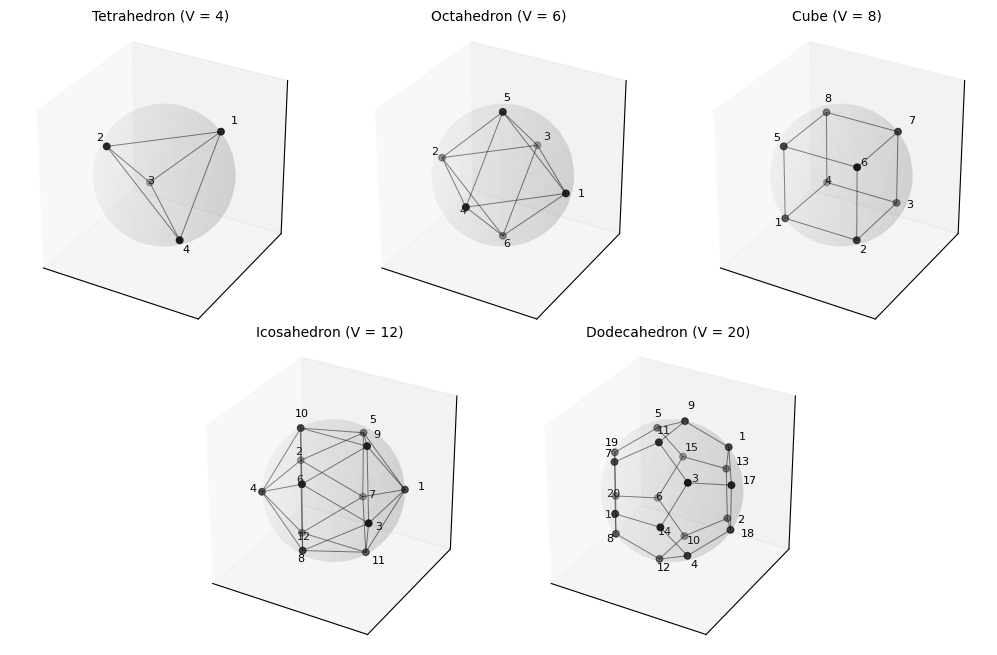

In [4]:
# === Plot all five solids on the Bloch sphere ===

# Polyhedron edge lists (1-indexed). Copied verbatim from
# paper/figures/platonic_solid_povms.tex, so the rendered wireframe matches
# the thesis figure.
EDGES = {
    "tetrahedron": [
        (1, 2), (1, 3), (1, 4),
        (2, 3), (2, 4), (3, 4),
    ],
    "octahedron": [
        (1, 3), (1, 4), (1, 5), (1, 6),
        (2, 3), (2, 4), (2, 5), (2, 6),
        (3, 5), (3, 6), (4, 5), (4, 6),
    ],
    "cube": [
        (1, 2), (2, 3), (3, 4), (4, 1),
        (5, 6), (6, 7), (7, 8), (8, 5),
        (1, 5), (2, 6), (3, 7), (4, 8),
    ],
    "icosahedron": [
        (1, 3),  (1, 5),  (1, 7),  (1, 9),  (1, 11),
        (2, 4),  (4, 6),  (4, 8),  (4, 10), (4, 12),
        (3, 9),  (5, 9),  (5, 7),  (7, 11), (3, 11),
        (2, 10), (6, 10), (6, 8),  (8, 12), (2, 12),
        (6, 9),  (3, 6),  (5, 10), (9, 10), (2, 7),
        (2, 5),  (11, 12),(7, 12), (3, 8),  (8, 11),
    ],
    "dodecahedron": [
        (1, 9),  (1, 13), (1, 17),
        (2, 10), (2, 13), (2, 18),
        (3, 11), (3, 14), (3, 17),
        (4, 12), (4, 14), (4, 18),
        (5, 9),  (5, 15), (5, 19),
        (6, 10), (6, 15), (6, 20),
        (7, 11), (7, 16), (7, 19),
        (8, 12), (8, 16), (8, 20),
        (9, 11), (10, 12),(13, 15),
        (14, 16),(17, 18),(19, 20),
    ],
}


def to_float_array(verts):
    """Convert tuple of sympy Matrix vertices to a (V, 3) numpy float array."""
    return np.array([[float(n[0]), float(n[1]), float(n[2])] for n in verts])


titles = {
    "tetrahedron":  "Tetrahedron (V = 4)",
    "octahedron":   "Octahedron (V = 6)",
    "cube":         "Cube (V = 8)",
    "icosahedron":  "Icosahedron (V = 12)",
    "dodecahedron": "Dodecahedron (V = 20)",
}

# Wireframe sphere mesh
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 20)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))

# 6-column grid: top row holds tet / oct / cube spanning columns (0,2,4) of
# width 2; bottom row holds icosa / dodeca centered at columns (1,3) of
# width 2. This avoids leaving an empty 6th subplot in a 2x3 layout.
fig = plt.figure(figsize=(13, 8))
gs = gridspec.GridSpec(2, 6, figure=fig, wspace=0.05, hspace=0.05)
positions = [
    ("tetrahedron",  gs[0, 0:2]),
    ("octahedron",   gs[0, 2:4]),
    ("cube",         gs[0, 4:6]),
    ("icosahedron",  gs[1, 1:3]),
    ("dodecahedron", gs[1, 3:5]),
]

for name, pos in positions:
    ax = fig.add_subplot(pos, projection="3d")
    ax.plot_surface(xs, ys, zs, color="lightgray", alpha=0.10,
                    linewidth=0, antialiased=True)

    pts = to_float_array(VERTICES[name])

    # Polyhedron wireframe edges (thin, slightly translucent)
    for i, j in EDGES[name]:
        p1, p2 = pts[i - 1], pts[j - 1]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
                color="black", linewidth=0.7, alpha=0.55)

    # Vertices + index labels offset radially outward
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2],
               color="black", s=22, depthshade=True)
    for k, p in enumerate(pts, 1):
        ax.text(1.18 * p[0], 1.18 * p[1], 1.18 * p[2],
                str(k), fontsize=8)

    ax.set_title(titles[name], fontsize=10)
    ax.set_xlim(-1.25, 1.25)
    ax.set_ylim(-1.25, 1.25)
    ax.set_zlim(-1.25, 1.25)
    ax.set_box_aspect([1, 1, 1])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

plt.show()

## Section 2 -- POVM elements and completeness

The POVM element associated with vertex $\hat n_k$ is
$$E_k \;=\; \frac{1}{V}\bigl(\mathbf{I} + \hat n_k \cdot \vec\sigma\bigr).$$
Each $E_k$ is positive semidefinite of rank one, with trace $\operatorname{tr}(E_k) = 2/V$, and the
collection satisfies $\sum_k E_k = \mathbf{I}$.

In [5]:
# === POVM elements ===

def povm_elements(vertices):
    """E_k = (1/V) (I + n_k . sigma) as symbolic 2x2 matrices."""
    V = len(vertices)
    inv = Rational(1, V)
    return tuple(
        inv * (eye(2) + n[0] * SIGMA_X + n[1] * SIGMA_Y + n[2] * SIGMA_Z)
        for n in vertices
    )


# Display the four tetrahedron POVM elements. `display()` renders sympy
# matrices as LaTeX in Jupyter (and via MathJax on GitHub); falls back to
# repr in plain text contexts.
tetra_E = povm_elements(VERTICES["tetrahedron"])
for k, E in enumerate(tetra_E, 1):
    print(f"E_{k} =")
    display(E)

E_1 =


Matrix([
[         sqrt(3)/12 + 1/4, sqrt(3)/12 - sqrt(3)*I/12],
[sqrt(3)/12 + sqrt(3)*I/12,          1/4 - sqrt(3)/12]])

E_2 =


Matrix([
[          sqrt(3)/12 + 1/4, -sqrt(3)/12 + sqrt(3)*I/12],
[-sqrt(3)/12 - sqrt(3)*I/12,           1/4 - sqrt(3)/12]])

E_3 =


Matrix([
[          1/4 - sqrt(3)/12, -sqrt(3)/12 - sqrt(3)*I/12],
[-sqrt(3)/12 + sqrt(3)*I/12,           sqrt(3)/12 + 1/4]])

E_4 =


Matrix([
[         1/4 - sqrt(3)/12, sqrt(3)/12 + sqrt(3)*I/12],
[sqrt(3)/12 - sqrt(3)*I/12,          sqrt(3)/12 + 1/4]])

In [6]:
# === Verify sum_k E_k = I for all five solids ===

for name, verts in VERTICES.items():
    elements = povm_elements(verts)
    total = elements[0].copy()
    for E in elements[1:]:
        total = total + E
    diff = total - eye(2)
    for i in range(2):
        for j in range(2):
            assert simplify(diff[i, j]) == 0, (
                f"{name} completeness failed at [{i},{j}]"
            )
    print(f"  {name:13s}  OK sum_k E_k = I")

  tetrahedron    OK sum_k E_k = I
  octahedron     OK sum_k E_k = I
  cube           OK sum_k E_k = I
  icosahedron    OK sum_k E_k = I
  dodecahedron   OK sum_k E_k = I


## Section 3 -- Informational Completeness

A POVM $\{E_k\}$ is **informationally complete** (IC) iff the effects span the real vector
space of Hermitian operators on $\mathbb{C}^2$ -- equivalently, iff the measurement
statistics $p_k = \operatorname{tr}(\rho E_k)$ uniquely determine $\rho$.

In dimension $d = 2$, the space of Hermitian operators is 4-dimensional over $\mathbb{R}$, so
IC requires at least $V \ge 4$ effects with appropriate linear independence. Below we run two
symbolic checks, the second strictly stronger; both pass for all five solids.

### Check 1 -- rank of the vec'd-effect matrix

Expand each effect in the orthogonal Pauli basis $\{\mathbf{I}, \sigma_x, \sigma_y, \sigma_z\}$:
$$E_k = a_0^{(k)} \mathbf{I} + a_x^{(k)} \sigma_x + a_y^{(k)} \sigma_y + a_z^{(k)} \sigma_z.$$
Stack the coefficients into a $V \times 4$ matrix $M$ whose row $k$ is
$(a_0^{(k)}, a_x^{(k)}, a_y^{(k)}, a_z^{(k)})$. The POVM is IC iff $\operatorname{rank}(M) = 4$
(the effects span $\mathrm{Herm}(\mathbb{C}^2)$, which is 4-dimensional).

Extracting the coefficients via the Hilbert--Schmidt identity
$a_\mu = \tfrac{1}{2}\operatorname{tr}(\sigma_\mu E_k)$ (with $\sigma_0 = \mathbf{I}$) gives, on
a $2 \times 2$ matrix:
$$a_0 = \tfrac{1}{2}(E_{00} + E_{11}), \quad a_x = \tfrac{1}{2}(E_{01} + E_{10}), \quad a_y = \tfrac{i}{2}(E_{01} - E_{10}), \quad a_z = \tfrac{1}{2}(E_{00} - E_{11}).$$

(Reading these off directly is cheaper than computing the trace -- $E_k$ is a known
$2 \times 2$ matrix.)

In [7]:
# === Pauli-basis matrix for the tetrahedron, displayed and rank-checked ===

def pauli_coeffs(E):
    """Decompose a 2x2 effect into (a0, ax, ay, az) along {I, sigma_x, sigma_y, sigma_z}."""
    a0 = (E[0, 0] + E[1, 1]) / 2
    ax = (E[0, 1] + E[1, 0]) / 2
    ay = symI * (E[0, 1] - E[1, 0]) / 2
    az = (E[0, 0] - E[1, 1]) / 2
    return [simplify(a0), simplify(ax), simplify(ay), simplify(az)]


# Default iszerofunc only inspects .is_zero, which returns None for some
# Q(sqrt(5)) expressions and over-reports rank. We force simplification first.
def is_zero_simplified(x):
    return simplify(x).is_zero


M_tetra = Matrix([pauli_coeffs(E) for E in tetra_E])
print("Vec'd-effect matrix for the tetrahedron")
print("(rows = effects, columns = I / sigma_x / sigma_y / sigma_z):")
display(M_tetra)
print(f"rank(M) = {M_tetra.rank(iszerofunc=is_zero_simplified)}   (need 4 for IC)")

Vec'd-effect matrix for the tetrahedron
(rows = effects, columns = I / sigma_x / sigma_y / sigma_z):


Matrix([
[1/4,  sqrt(3)/12,  sqrt(3)/12,  sqrt(3)/12],
[1/4, -sqrt(3)/12, -sqrt(3)/12,  sqrt(3)/12],
[1/4, -sqrt(3)/12,  sqrt(3)/12, -sqrt(3)/12],
[1/4,  sqrt(3)/12, -sqrt(3)/12, -sqrt(3)/12]])

rank(M) = 4   (need 4 for IC)


In [8]:
# === Rank check for all five solids ===
# Output collected and printed at the end. Without this, sympy pauses
# between the larger solids (icosa, dodeca) cause Jupyter to split the
# stdout into separate stream events, which render with blank-line gaps.

lines = []
for name, verts in VERTICES.items():
    elements = povm_elements(verts)
    M = Matrix([pauli_coeffs(E) for E in elements])
    r = M.rank(iszerofunc=is_zero_simplified)
    assert r == 4, f"{name} has vec'd-effect rank {r}, expected 4"
    lines.append(f"  {name:13s}  rank = {r}/4   OK IC")
print("\n".join(lines))

  tetrahedron    rank = 4/4   OK IC
  octahedron     rank = 4/4   OK IC
  cube           rank = 4/4   OK IC
  icosahedron    rank = 4/4   OK IC
  dodecahedron   rank = 4/4   OK IC


### Check 2 -- the second-moment identity

A second, strictly stronger characterization: the second moment of the projectors
$|\psi_k\rangle\!\langle\psi_k|$ averaged over the POVM equals (up to dimension factors) the
projector onto the symmetric subspace of $(\mathbb{C}^2)^{\otimes 2}$:
$$\frac{1}{V}\sum_k |\psi_k\rangle\!\langle\psi_k|^{\otimes 2} \;=\; \frac{1}{6}\bigl(\mathbf{I}_4 + \mathrm{SWAP}_{12}\bigr).$$

We compute the left-hand side entirely in the Bloch parametrization. Since
$|\psi_k\rangle\!\langle\psi_k|$ is the rank-1 projector onto the eigenstate of
$\hat n_k \cdot \vec\sigma$ with eigenvalue $+1$, it satisfies
$$|\psi_k\rangle\!\langle\psi_k| \;=\; \tfrac{1}{2}\bigl(\mathbf{I} + \hat n_k \cdot \vec\sigma\bigr).$$
The tensor square is then a polynomial in the components of $\hat n_k$ alone -- *no phase
representative for $|\psi_k\rangle$ ever needs to be chosen*. This is what keeps the whole
appendix inside the real field each solid's coordinates already live in.

In [9]:
# === Second-moment identity, tetrahedron, explicitly ===

def rho_from_bloch(n):
    """rho = (1/2) (I + n . sigma) -- rank-1 projector for ||n|| = 1."""
    return (eye(2) + n[0] * SIGMA_X + n[1] * SIGMA_Y + n[2] * SIGMA_Z) / 2


verts = VERTICES["tetrahedron"]
V = len(verts)

LHS = zeros(4, 4)
for n in verts:
    rho = rho_from_bloch(n)
    LHS = LHS + kron(rho, rho)
LHS = (LHS / V).applyfunc(simplify)

RHS = (eye(4) + SWAP4) / 6

print("(1/V) sum_k rho_k (x) rho_k for the tetrahedron =")
display(LHS)
print("(1/6) (I_4 + SWAP) =")
display(RHS)
print("LHS - RHS =")
display(LHS - RHS)

for i in range(4):
    for j in range(4):
        assert simplify(LHS[i, j] - RHS[i, j]) == 0
print("OK second-moment identity holds for the tetrahedron")

(1/V) sum_k rho_k (x) rho_k for the tetrahedron =


Matrix([
[1/3,   0,   0,   0],
[  0, 1/6, 1/6,   0],
[  0, 1/6, 1/6,   0],
[  0,   0,   0, 1/3]])

(1/6) (I_4 + SWAP) =


Matrix([
[1/3,   0,   0,   0],
[  0, 1/6, 1/6,   0],
[  0, 1/6, 1/6,   0],
[  0,   0,   0, 1/3]])

LHS - RHS =


Matrix([
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0],
[0, 0, 0, 0]])

OK second-moment identity holds for the tetrahedron


In [10]:
# === Second-moment identity for all five solids ===

target = (eye(4) + SWAP4) / 6

lines = []
for name, verts in VERTICES.items():
    V = len(verts)
    total = zeros(4, 4)
    for n in verts:
        rho = rho_from_bloch(n)
        total = total + kron(rho, rho)
    diff = total / V - target
    for i in range(4):
        for j in range(4):
            assert simplify(diff[i, j]) == 0, (
                f"{name} second-moment failed at [{i},{j}]"
            )
    lines.append(f"  {name:13s}  OK (1/V) sum_k rho_k (x) rho_k = (1/6)(I + SWAP)")
print("\n".join(lines))

  tetrahedron    OK (1/V) sum_k rho_k (x) rho_k = (1/6)(I + SWAP)
  octahedron     OK (1/V) sum_k rho_k (x) rho_k = (1/6)(I + SWAP)
  cube           OK (1/V) sum_k rho_k (x) rho_k = (1/6)(I + SWAP)
  icosahedron    OK (1/V) sum_k rho_k (x) rho_k = (1/6)(I + SWAP)
  dodecahedron   OK (1/V) sum_k rho_k (x) rho_k = (1/6)(I + SWAP)


## Section 4 -- Frame potential and Welch bound (projective designs)

The **frame potential** of a set of unit vectors $\{|\psi_k\rangle\}_{k=1}^V \subset \mathbb{C}^d$ at level $t$ is
$$\Phi_t \;=\; \frac{1}{V^2} \sum_{i, j} |\langle\psi_i | \psi_j\rangle|^{2t}.$$
On $\mathbb{CP}^{d-1}$, it satisfies the **Welch lower bound**
$$\Phi_t \;\ge\; \binom{d + t - 1}{t}^{-1} \;=\; \frac{1}{t + 1} \quad (\text{for } d = 2).$$
A set $\{|\psi_k\rangle\}$ is a **complex projective $t$-design** iff $\Phi_k = 1/(k + 1)$ for
every $k \le t$. The largest such $t$ is the *projective design strength* $t_p$.

For Bloch vectors we never need to materialize $|\psi_k\rangle$ -- the **Bloch identity**
$$|\langle\psi_i | \psi_j\rangle|^2 \;=\; \tfrac{1}{2}\bigl(1 + \hat n_i \cdot \hat n_j\bigr)$$
turns $\Phi_t$ into a closed-form polynomial in the dot products $\hat n_i \cdot \hat n_j$.

In [11]:
# === Frame potential and Welch bound ===

def frame_potential(vertices, t):
    """Phi_t = (1/V^2) sum_{i,j} |<psi_i|psi_j>|^{2t}, via the Bloch identity."""
    V = len(vertices)
    total = Rational(0)
    for i in range(V):
        ni = vertices[i]
        for j in range(V):
            nj = vertices[j]
            dot = ni[0] * nj[0] + ni[1] * nj[1] + ni[2] * nj[2]
            overlap_sq = (1 + dot) / 2
            total = total + overlap_sq ** t
    return simplify(total / V ** 2)


def welch_bound(t):
    """1/(t+1) -- Welch lower bound on Phi_t for d = 2."""
    return Rational(1, t + 1)

In [12]:
# === Phi_t for the tetrahedron, t = 1..5 ===

print(f"{'t':>2}  {'Phi_t':>14}  {'Welch 1/(t+1)':>14}  saturates?")
print("-" * 55)
for t in range(1, 6):
    phi = frame_potential(VERTICES["tetrahedron"], t)
    wb = welch_bound(t)
    flag = "yes" if simplify(phi - wb) == 0 else ""
    print(f"{t:>2}  {str(phi):>14}  {str(wb):>14}  {flag}")

 t           Phi_t   Welch 1/(t+1)  saturates?
-------------------------------------------------------
 1             1/2             1/2  yes
 2             1/3             1/3  yes
 3            5/18             1/4  
 4            7/27             1/5  
 5          41/162             1/6  


In [13]:
# === Summary: Phi_2..Phi_5 and projective design strength t_p ===

def projective_design_strength(vertices, t_max=6):
    """Largest t with Phi_k = 1/(k+1) for all k <= t (consecutive saturation)."""
    last = 0
    for t in range(1, t_max + 1):
        if simplify(frame_potential(vertices, t) - welch_bound(t)) != 0:
            return last
        last = t
    return last


def fmt(val, saturates):
    s = str(val)
    return f"{s}*" if saturates else s


header = (f"{'Solid':14s} {'V':>3s} {'t_p':>4s}  "
          f"{'Phi_2':>10s}  {'Phi_3':>10s}  {'Phi_4':>14s}  {'Phi_5':>14s}")
lines = [header, "-" * len(header)]
for name, verts in VERTICES.items():
    V = len(verts)
    t_p = projective_design_strength(verts)
    cells = []
    for t in (2, 3, 4, 5):
        phi = frame_potential(verts, t)
        sat = simplify(phi - welch_bound(t)) == 0
        cells.append(fmt(phi, sat))
    lines.append(f"{name:14s} {V:>3d} {t_p:>4d}  "
                 f"{cells[0]:>10s}  {cells[1]:>10s}  {cells[2]:>14s}  {cells[3]:>14s}")
lines.append("")
lines.append("(asterisk * marks Welch-bound saturation; t_p is the largest t with "
             "consecutive saturation through t)")
print("\n".join(lines))

Solid            V  t_p       Phi_2       Phi_3           Phi_4           Phi_5
-------------------------------------------------------------------------------
tetrahedron      4    2        1/3*        5/18            7/27          41/162
octahedron       6    3        1/3*        1/4*            5/24            3/16
cube             8    3        1/3*        1/4*           11/54          19/108
icosahedron     12    5        1/3*        1/4*            1/5*            1/6*
dodecahedron    20    5        1/3*        1/4*            1/5*            1/6*

(asterisk * marks Welch-bound saturation; t_p is the largest t with consecutive saturation through t)


## Section 5 -- Spherical design strength

A finite set $X \subset S^2$ is a **spherical $t$-design** if the discrete average over $X$
equals the uniform surface integral for every polynomial $f$ of total degree $\le t$:
$$\frac{1}{|X|} \sum_{x \in X} f(x) \;=\; \frac{1}{4\pi} \int_{S^2} f \, \mathrm{d}\sigma \quad \text{for all } \deg f \le t.$$
By linearity, this reduces to checking the identity for all monomials
$x_1^{a_1} x_2^{a_2} x_3^{a_3}$ with $a_1 + a_2 + a_3 \le t$ -- equivalently, the moment-tensor
identity
$$\frac{1}{V} \sum_k \hat n_k^{\otimes t} \;=\; \frac{1}{4\pi} \int_{S^2} \hat n^{\otimes t} \, \mathrm{d}\sigma.$$

The right-hand side has a closed form:
$$\frac{1}{4\pi} \int_{S^2} x_1^{a_1} x_2^{a_2} x_3^{a_3} \, \mathrm{d}\sigma \;=\;
\begin{cases}
\dfrac{(a_1 - 1)!! \, (a_2 - 1)!! \, (a_3 - 1)!!}{(a_1 + a_2 + a_3 + 1)!!} & \text{all } a_i \text{ even}, \\[6pt]
0 & \text{some } a_i \text{ odd},
\end{cases}$$
with the convention $(-1)!! = 0!! = 1$. The odd-$a_i$ monomials vanish under the reflection
symmetry $x_i \to -x_i$ of the sphere measure.

In [14]:
# === Sphere moment via the closed form ===

def double_factorial(n):
    """n!! with the convention (-1)!! = 0!! = 1."""
    if n <= 0:
        return Rational(1)
    result = Rational(1)
    while n > 0:
        result *= n
        n -= 2
    return result


def sphere_moment(indices):
    """(1/4 pi) integral_{S^2} x_{i_1} ... x_{i_t} d sigma, via the closed form.

    `indices` is a tuple in {0, 1, 2}^t (x = 0, y = 1, z = 2).
    """
    a = [0, 0, 0]
    for i in indices:
        a[i] += 1
    if any(ai % 2 for ai in a):
        return Rational(0)
    num = (double_factorial(a[0] - 1)
           * double_factorial(a[1] - 1)
           * double_factorial(a[2] - 1))
    den = double_factorial(a[0] + a[1] + a[2] + 1)
    return num / den


# Spot checks: <x^2> = 1/3, <x^4> = 1/5, <x^2 y^2> = 1/15, <x y z> = 0.
print(f"<x^2>     = {sphere_moment((0, 0))}     (expect 1/3)")
print(f"<x^4>     = {sphere_moment((0, 0, 0, 0))}     (expect 1/5)")
print(f"<x^2 y^2> = {sphere_moment((0, 0, 1, 1))}    (expect 1/15)")
print(f"<x y z>   = {sphere_moment((0, 1, 2))}     (expect 0, odd parity)")

<x^2>     = 1/3     (expect 1/3)
<x^4>     = 1/5     (expect 1/5)
<x^2 y^2> = 1/15    (expect 1/15)
<x y z>   = 0     (expect 0, odd parity)


In [15]:
# === Spherical design strength via moment-tensor matching ===

def spherical_design_strength(vertices, t_max=6):
    """Largest t such that (1/V) sum_k n_k^{(x)t} = sphere_moment(indices)
    for every multi-index of length t."""
    V = len(vertices)
    last = 0
    for t in range(1, t_max + 1):
        good = True
        for indices in product(range(3), repeat=t):
            discrete = Rational(0)
            for n in vertices:
                term = Rational(1)
                for i in indices:
                    term *= n[i]
                discrete = discrete + term
            discrete = simplify(discrete / V)
            cont = sphere_moment(indices)
            if simplify(discrete - cont) != 0:
                good = False
                break
        if not good:
            return last
        last = t
    return last

In [16]:
# === Spherical and projective design strengths, side by side ===

lines = [f"{'Solid':14s}  {'V':>3s}  {'t_s':>4s}  {'t_p':>4s}", "-" * 35]
for name, verts in VERTICES.items():
    t_s = spherical_design_strength(verts)
    t_p = projective_design_strength(verts)
    lines.append(f"{name:14s}  {len(verts):>3d}  {t_s:>4d}  {t_p:>4d}")
print("\n".join(lines))

Solid             V   t_s   t_p
-----------------------------------
tetrahedron       4     2     2
octahedron        6     3     3
cube              8     3     3
icosahedron      12     5     5
dodecahedron     20     5     5


### Note on the projective $\leftrightarrow$ spherical connection

For *centrally symmetric* vertex sets (all four non-tetrahedral solids), the Bloch identity
$|\langle\psi_i | \psi_j\rangle|^{2t} = \bigl((1 + \hat n_i \cdot \hat n_j)/2\bigr)^t$ is a
*homogeneous* polynomial of degree $2t$ in the components of $\hat n_i, \hat n_j$. Combined
with central symmetry, this ties spherical and projective strengths tightly together. The
tetrahedron is the exception -- it lacks central symmetry, so its odd moments don't
automatically vanish and need a direct check.

The table above shows $t_s = t_p$ for every solid. This is *not* a coincidence: it's the
discrete-moment / Welch-saturation correspondence in $d = 2$. Deriving it isn't the point of
this notebook -- here we just report both numbers and let the reader confirm they agree.

## Section 6 -- Pairwise overlap multisets

The closed-form multiset $\{|\langle\psi_i | \psi_j\rangle|^2 : i < j\}$ exposes the
*equiangularity structure* of each POVM. Computed once via the Bloch identity
$|\langle\psi_i | \psi_j\rangle|^2 = \tfrac{1}{2}(1 + \hat n_i \cdot \hat n_j)$,
then collected by symbolic-equality binning.

Patterns visible in the output:

- The **tetrahedron** is *equiangular*: one distinct overlap value $1/3$ with multiplicity
  $\binom{4}{2} = 6$. This is the defining property of a SIC-POVM.
- The four **centrally symmetric** solids (octa, cube, icosa, dodeca) all have multiplicity
  $V/2$ at value $0$: antipodal pairs are orthogonal.
- The **icosahedron** is the *tight* projective 5-design -- the only one on $\mathbb{CP}^1$
  with irrational angle set (Lyubich 2007). Its two non-zero overlap values are
  $(\tau + 2)/5$ and $(3 - \tau)/5$.

Multiplicities sum to $\binom{V}{2}$ for each solid.

In [17]:
# === Pairwise overlap multisets ===

from sympy import Symbol

# Display-only symbol named "tau" so values like 1/2 + sqrt(5)/10 print in the
# golden-ratio form 2/5 + tau/5 -- matching the thesis tables and the
# stdout of `povm_properties.py`. Kept distinct from the numeric `tau` above
# (which is the actual radical (1 + sqrt(5))/2 used in the math); this symbol
# is only ever used for display, never reinjected into computations.
_tau_display = Symbol("tau")


def golden_form(val):
    """If val = a + b*sqrt(5), rewrite as (a - b) + 2*b*tau using
    sqrt(5) = 2*tau - 1. Leaves expressions without sqrt(5) unchanged."""
    expr = simplify(val)
    coeffs = expr.as_coefficients_dict()
    a = coeffs.get(1, 0)
    b = coeffs.get(sqrt(5), 0)
    if b == 0 or simplify(expr - a - b * sqrt(5)) != 0:
        return expr
    return (a - b) + 2 * b * _tau_display


def angle_multiset(vertices):
    """Multiset {|<psi_i|psi_j>|^2 : i < j} as a list of (value, multiplicity)
    pairs, sorted by descending value."""
    V = len(vertices)
    bins = []  # list of [value, multiplicity]
    for i in range(V):
        for j in range(i + 1, V):
            ni, nj = vertices[i], vertices[j]
            dot = ni[0] * nj[0] + ni[1] * nj[1] + ni[2] * nj[2]
            val = simplify((1 + dot) / 2)
            for entry in bins:
                if simplify(entry[0] - val) == 0:
                    entry[1] += 1
                    break
            else:
                bins.append([val, 1])
    bins.sort(key=lambda e: -float(e[0].evalf()))
    return [(v, c) for v, c in bins]


lines = []
for name, verts in VERTICES.items():
    V = len(verts)
    angles = angle_multiset(verts)
    total = sum(c for _, c in angles)
    expected = comb(V, 2)
    lines.append(f"{name} (V = {V}, expect sum = C({V},2) = {expected}):")
    for val, count in angles:
        lines.append(f"    {count:3d}  x  {golden_form(val)}")
    assert total == expected, (
        f"{name}: multiplicities sum to {total}, expected {expected}"
    )
    lines.append("")
print("\n".join(lines))

tetrahedron (V = 4, expect sum = C(4,2) = 6):
      6  x  1/3

octahedron (V = 6, expect sum = C(6,2) = 15):
     12  x  1/2
      3  x  0

cube (V = 8, expect sum = C(8,2) = 28):
     12  x  2/3
     12  x  1/3
      4  x  0

icosahedron (V = 12, expect sum = C(12,2) = 66):
     30  x  tau/5 + 2/5
     30  x  3/5 - tau/5
      6  x  0

dodecahedron (V = 20, expect sum = C(20,2) = 190):
     30  x  tau/3 + 1/3
     60  x  2/3
     60  x  1/3
     30  x  2/3 - tau/3
     10  x  0



## Section 7 -- Dual alignment and the covariance copy

Two facts the vertex tables silently encode; the thesis takes them up in the Appendix E
section on the two icosahedral families.

**Dual alignment.** The dual of a Platonic solid has one vertex per face -- the outward unit
normal at the face's center. Being dual is a property of the *shapes*; being
**dual-aligned** is a property of the *coordinate sets*: every vertex of one solid must be
the actual normalized face center of the other, not merely congruent to one. Our tables list
every pair aligned: octahedron $\leftrightarrow$ cube, icosahedron $\leftrightarrow$
dodecahedron, and the self-dual tetrahedron $\leftrightarrow$ its antipodal copy.

**The covariance copy.** For the icosahedral pair, alignment is a real choice. The equally
standard mirror convention for the icosahedron -- cyclic permutations of $(0, \pm 1, \pm\tau)$
instead of our $(0, \pm\tau, \pm 1)$ -- differs from ours by one *transposition* of coordinate
axes, and is **not** dual-aligned with the dodecahedron tabulated here. No rotation that fixes
the labeled Pauli axes maps one convention to the other (an axis transposition does --
equivalently the half-turn about $\hat x - \hat z$, itself an octahedral rotation, which is
exactly why the octahedron and cube are immune to the choice). Which family is tabulated
decides which anchored copy of $2\mathcal{I}$ is the POVM's covariance group: ours pairs with
$\langle X, Z, F, \Phi \rangle$, the mirror with $\langle X, Z, F, \Phi^\star \rangle$, where
$\Phi^\star$ is the entry-wise image of $\Phi$ under $\sqrt 5 \mapsto -\sqrt 5$ (Eq.
(golden-gate) of the thesis).

Both checks below locate candidate matches numerically -- a float distance above $10^{-6}$ is
conclusive against ${\sim}10^{-15}$ arithmetic error -- and then decide every verdict
symbolically: a match entry-by-entry against its candidate, a miss by a witness effect
confirmed to differ from every tabulated effect.

In [18]:
# === Dual alignment: every vertex of one solid is a face center of its dual ===

def verify_dual_alignment(vertices_a, vertices_b, face_size):
    """Every vertex a of solid A is the outward center of a face of solid B:
    the face_size vertices of B nearest to a (by Bloch overlap) have exactly
    equal overlaps, strictly larger than every other vertex's, and their
    centroid is a positive multiple of a. Face membership and the strict gap
    are located numerically; overlap equality and parallelism (vanishing
    cross product) are then exact."""
    for k, a in enumerate(vertices_a, 1):
        dots = [a.dot(b) for b in vertices_b]
        vals = [float(d.evalf(20)) for d in dots]
        order = sorted(range(len(vals)), key=vals.__getitem__, reverse=True)
        face, rest = order[:face_size], order[face_size:]
        # Clean overlap gap after face_size vertices: the face is well-defined.
        assert vals[face[-1]] > vals[rest[0]] + 1e-6, f"vertex {k}: no gap"
        for j in face[1:]:
            assert simplify(dots[face[0]] - dots[j]) == 0, (
                f"vertex {k}: face overlaps unequal"
            )
        centroid = zeros(3, 1)
        for j in face:
            centroid = centroid + vertices_b[j]
        cross = a.cross(centroid)
        for i in range(3):
            assert simplify(cross[i]) == 0, f"vertex {k}: centroid not parallel"
        assert float(a.dot(centroid).evalf(20)) > 1e-6, (
            f"vertex {k}: centroid anti-parallel"
        )


for name_a, name_b, face_size in (
    ("octahedron",   "cube",         4),
    ("cube",         "octahedron",   3),
    ("icosahedron",  "dodecahedron", 5),
    ("dodecahedron", "icosahedron",  3),
):
    verify_dual_alignment(VERTICES[name_a], VERTICES[name_b], face_size)
    print(f"  {name_a:13s} vertices are {name_b} face centers  OK")

antipodal_tetra = tuple(-v for v in VERTICES["tetrahedron"])
verify_dual_alignment(antipodal_tetra, VERTICES["tetrahedron"], 3)
print("  tetrahedron   face centers are its antipodal copy    OK")

  octahedron    vertices are cube face centers  OK
  cube          vertices are octahedron face centers  OK
  icosahedron   vertices are dodecahedron face centers  OK


  dodecahedron  vertices are icosahedron face centers  OK
  tetrahedron   face centers are its antipodal copy    OK


### The gates $F$, $\Phi$, $\Phi^\star$

$F = HS^\dagger$ lies in $2\mathcal{T}$ up to phase, hence in all three binary polyhedral groups, so
conjugation by it must permute all five effect sets. $\Phi$'s Bloch rotation is a
72-degree turn about an icosahedron vertex axis -- a symmetry of the icosahedral pair and of
nothing else here (no other solid has a 5-fold axis). And $\Phi^\star$ generates the *other*
anchored copy, whose solids are the mirror-family ones we did not tabulate: it should permute
none of the five.

In [19]:
# === The covariance copy: conjugation by F, Phi, Phi* ===

F_GATE = (1 / sqrt(2)) * Matrix([[1, 1], [1, -1]]) * Matrix([[1, 0], [0, symI]]).H
PHI = Rational(1, 2) * Matrix([
    [tau + symI * sigma, 1],
    [-1, tau - symI * sigma],
])                                        # Eq. (golden-gate) of the thesis
PHI_STAR = PHI.subs(sqrt(5), -sqrt(5))    # its entry-wise sqrt(5) -> -sqrt(5) image


def to_complex_tuple(E):
    """Flatten a symbolic 2x2 matrix into a tuple of Python complex numbers."""
    return tuple(complex(E[i, j].evalf(20)) for i in range(2) for j in range(2))


def conjugation_permutation(U, elements):
    """The permutation k -> j with U E_k U^dagger = E_j, or None if
    conjugation by U does not map the effect set to itself."""
    Ud = U.H
    originals = [to_complex_tuple(E) for E in elements]
    perm = []
    for k, E in enumerate(elements):
        C = U * E * Ud
        cf = to_complex_tuple(C)
        dists = [max(abs(x - y) for x, y in zip(cf, o)) for o in originals]
        j = min(range(len(dists)), key=dists.__getitem__)
        if dists[j] > 1e-6:
            # Assert the margin rather than trust the threshold: a "does not
            # permute" verdict rests entirely on this miss, and most of the
            # fifteen verdicts below are misses. The separation is two-sided
            # and enormous -- true matches land at <= 6.5e-27, misses at
            # >= 8.9e-3 -- so anything in between is a near-miss nobody
            # intended, and it should raise rather than quietly read as "no".
            assert dists[j] > 1e-3, (
                f"effect {k} is neither a match nor a clean miss: "
                f"best distance {dists[j]}"
            )
            # The miss only proposes the verdict; one witness decides it:
            # this effect's image differs from EVERY tabulated effect, each
            # difference confirmed symbolically, so no permutation can exist.
            for Ej in elements:
                assert any(simplify(C[row, col] - Ej[row, col]) != 0
                           for row in range(2) for col in range(2)), (
                    f"float miss contradicted symbolically: effect {k}'s "
                    f"image is a tabulated effect"
                )
            return None
        for row in range(2):
            for col in range(2):
                assert simplify(C[row, col] - elements[j][row, col]) == 0, (
                    f"numeric match {k} -> {j} failed symbolic confirmation"
                )
        perm.append(j)
    assert sorted(perm) == list(range(len(elements))), f"not a bijection: {perm}"
    return perm


EXPECTED = {
    "F":    {"tetrahedron": True,  "octahedron": True,  "cube": True,
             "icosahedron": True,  "dodecahedron": True},
    "Phi":  {"tetrahedron": False, "octahedron": False, "cube": False,
             "icosahedron": True,  "dodecahedron": True},
    "Phi*": {"tetrahedron": False, "octahedron": False, "cube": False,
             "icosahedron": False, "dodecahedron": False},
}

for gate_name, U in (("F", F_GATE), ("Phi", PHI), ("Phi*", PHI_STAR)):
    permuted = []
    for name, verts in VERTICES.items():
        perm = conjugation_permutation(U, povm_elements(verts))
        got = perm is not None
        assert got == EXPECTED[gate_name][name], (
            f"conjugation by {gate_name} on {name}: "
            f"permutes={got}, expected {EXPECTED[gate_name][name]}"
        )
        if got:
            permuted.append(name)
    outcome = ", ".join(permuted) if permuted else "none"
    print(f"  conjugation by {gate_name + ':':5s} permutes {outcome}")

print("\n  covariance copy OK: the tabulated icosahedron and dodecahedron belong")
print("  to the <X,Z,F,Phi> family")

  conjugation by F:    permutes tetrahedron, octahedron, cube, icosahedron, dodecahedron


  conjugation by Phi:  permutes icosahedron, dodecahedron


  conjugation by Phi*: permutes none

  covariance copy OK: the tabulated icosahedron and dodecahedron belong
  to the <X,Z,F,Phi> family


## Closing notes

**What was shown:**

- All five Platonic-solid POVMs are informationally complete.
- The tetrahedron is a **2-design** -- the qubit SIC-POVM.
- The octahedron and cube are **3-designs** (the octahedron is the qubit MUB; both share
  the binary octahedral symmetry group $2\mathcal{O}$).
- The icosahedron and dodecahedron are **5-designs**; the icosahedron is the unique *tight*
  projective 5-design on $\mathbb{CP}^1$ with irrational angle set (Lyubich 2007).
- The spherical design strength $t_s$ equals the projective design strength $t_p$ for every
  solid -- a consequence of the Bloch parametrization combined with central symmetry,
  modulo the tetrahedron's odd-moment caveat.
- Every tabulated dual pair is **dual-aligned**, and the icosahedron/dodecahedron pair is
  covariant under the anchored copy $\langle X, Z, F, \Phi \rangle$ specifically:
  conjugation by $\Phi$ permutes their effects, conjugation by $\Phi^\star$ does not --
  the two-family story of the thesis's Appendix E.

**Cross-check status (the second purpose):**

The values computed above for $t_p$, $t_s$, $\Phi_t$, and the pairwise overlap multisets are
the ones that appear in Table E.3 (*Symbolic properties of the Platonic-solid POVMs*) of the
rendered thesis and in `povm_angle_multisets.tex` (*Pairwise-overlap multisets*;
repository-only, not printed). The next cell holds this notebook to that claim, against
`code/povm_properties.py` itself.

The agreement is computed here rather than left to your eye -- reading the numbers above
against the rendered appendix would be the one inexact link in an otherwise exact chain. The
independence is real and deliberate: this notebook decides every verdict with `simplify`, the
module decides each one by coercion into the solid's own number field, and two routes sharing
no mechanism agreeing is worth far more than either alone. But an independent verifier whose
verdict is never *computed* verifies nothing, and every sibling walkthrough in this repository
ends by computing its own -- the shadow notebook diffs 629 stored values at
`max |diff| = 0.0`, the $\Phi$ and numpy notebooks diff their primitives against the modules
they walk through.

The cell below is that computation, and it keeps the independence intact: it runs **this
notebook's** `simplify`-based functions and the **module's** field-based ones on their own
vertices, and compares the answers.

In [20]:
# === Discharge the cross-check: this notebook against povm_properties.py ===

import povm_properties as pp

report = []
for name in VERTICES:
    ours, theirs = VERTICES[name], pp.numeric_vertices(name)
    K = pp.solid_field(name)

    # 1. the vertex lists themselves, in order (the atlas indexes k by it)
    assert len(ours) == len(theirs), f"{name}: {len(ours)} vertices vs {len(theirs)}"
    for k, (a, b) in enumerate(zip(ours, theirs)):
        for i in range(3):
            assert simplify(a[i] - b[i]) == 0, f"{name}: vertex {k} component {i}"

    # 2. the design ladder: our simplify route against their field route
    t_s_ours, t_p_ours = spherical_design_strength(ours), projective_design_strength(ours)
    t_s_theirs = pp.spherical_design_strength(theirs, K)
    t_p_theirs = pp.projective_design_strength(theirs, K)
    assert t_s_ours == t_s_theirs and t_p_ours == t_p_theirs, \
        f"{name}: design strength {t_s_ours}/{t_p_ours} vs {t_s_theirs}/{t_p_theirs}"

    # 3. the frame potentials that Table E.3 prints
    for t in (1, 2, 3, 4, 5):
        assert simplify(frame_potential(ours, t) - pp.frame_potential(theirs, t)) == 0, \
            f"{name}: Phi_{t} differs"

    # 4. the overlap multiset that povm_angle_multisets.tex prints, value and multiplicity
    ours_ms, theirs_ms = angle_multiset(ours), pp.angle_multiset(theirs, K)
    assert len(ours_ms) == len(theirs_ms), f"{name}: {len(ours_ms)} bins vs {len(theirs_ms)}"
    for (v1, c1), (v2, c2) in zip(ours_ms, theirs_ms):
        assert c1 == c2 and simplify(v1 - v2) == 0, f"{name}: overlap bin {v1} vs {v2}"

    # 5. the DISPLAY vertices -- the ones write_vertex_atlas typesets. They are
    #    built from bare tau, sigma SYMBOLS so Table E.1 can print closed forms,
    #    so they are not the list checked in 1 and nothing above reaches them.
    #    Substitute THIS notebook's golden ratio back in and they must land on
    #    the same points.
    t_sym, s_sym = Symbol("tau"), Symbol("sigma")
    for k, (a, b) in enumerate(zip(ours, pp.display_vertices(name))):
        for i in range(3):
            assert simplify(a[i] - b[i].subs({t_sym: tau, s_sym: sigma})) == 0, \
                f"{name}: display vertex {k} component {i}"

    report.append((name, len(ours), t_s_ours, t_p_ours, len(ours_ms)))

print(f"  {'solid':<14}{'V':>3}{'t_s':>5}{'t_p':>5}{'overlap bins':>14}")
for name, V, t_s, t_p, nb in report:
    print(f"  {name:<14}{V:>3}{t_s:>5}{t_p:>5}{nb:>14}")
print("\nsimplify route == number-field route, on all five solids:")
print("  vertices in order, t_s, t_p, Phi_1..Phi_5, and the overlap multisets,")
print("  plus the display vertices Table E.1 typesets, under tau, sigma resubstitution.")

  solid           V  t_s  t_p  overlap bins
  tetrahedron     4    2    2             1
  octahedron      6    3    3             2
  cube            8    3    3             3
  icosahedron    12    5    5             3
  dodecahedron   20    5    5             5

simplify route == number-field route, on all five solids:
  vertices in order, t_s, t_p, Phi_1..Phi_5, and the overlap multisets,
  plus the display vertices Table E.1 typesets, under tau, sigma resubstitution.


That is the cross-check discharged. The LaTeX-table generators (`write_vertex_atlas`,
`write_properties`) live in the module and remain out of scope here -- what is now machine-
checked is every *number* those generators are handed, not the typesetting they do with it.

The two are handed *different* vertex lists, which is why step 5 exists. `write_properties`
receives the numeric vertices, which steps 1--4 compare; `write_vertex_atlas` receives the
**display** vertices, built from bare $\tau, \sigma$ symbols so that Table E.1 can show
$1/\sqrt{2 + \tau}$ rather than a nested radical. Checking only the first list would leave the
coordinates the vertex table actually prints resting on nothing, so step 5 substitutes this notebook's
own golden ratio into the second and lands on the same 50 points.

One thing the cell deliberately does **not** do: re-run the module's checks and report that
they passed. That would be the module verifying itself, with this notebook as a wrapper. What
it runs is both routes and compares them, which is the only arrangement in which the word
*independent* is doing any work.

The bonus section below explains why that agreement is worth more than it looks.

## Bonus -- why the production code decides none of this with `simplify`

Every verdict above was reached by `simplify(...) == 0`. The module this notebook verifies
reaches none of its verdicts that way: each check in `code/povm_properties.py` coerces its
expression into an algebraic number field and compares against that field's zero. This
notebook is left on `simplify` deliberately. Both halves of that are worth explaining,
and the second half is the more interesting one.

### What a decision procedure owes you

Two properties, both load-bearing:

1. **Canonical.** Any two expressions denoting the same number get the same representative --
   no tolerance, no dependence on how the expression happened to get written. The consequence
   that matters in practice is that a canonical representative is a **key**: it hashes, so it
   can back a `dict` or a `set`.
2. **Fail-loud.** A value from outside the declared field **raises**, instead of being quietly
   massaged into something that looks like it belongs.

`simplify` supplies neither. It is a heuristic with no normal-form guarantee -- two expressions
denoting the same algebraic number need not reduce to the same tree, and `simplify(x - y) == 0`
can return `False` when $x = y$. It could hardly be otherwise: deciding $x = 0$ for arbitrary
symbolic expressions is undecidable (Richardson's theorem). And it is silent by construction --
hand it a number with no business in the calculation and it hands back a tidier version of that
number.

Neither complaint is that `simplify` gets *these five solids* wrong. It does not; the notebook
above is the evidence. The complaint is that "it happens to be right here" is the only argument
available for it, and that argument has to be re-made from scratch every time the input changes.

### The replacement: one algebraic number field per solid

| solid | field | degree |
|---|---|---|
| octahedron | $\mathbb{Q}$ | 1 |
| tetrahedron, cube | $\mathbb{Q}(\sqrt 3)$ | 2 |
| icosahedron | $\mathbb{Q}(\sqrt{2 + \tau})$ | 4 |
| dodecahedron | $\mathbb{Q}(\sqrt 3, \sqrt 5)$ | 4 |

Coordinates coerce into `sympy`'s `QQ.algebraic_field(...)`, which supplies both properties for
free. Site by site:

| decision | the heuristic route | in the field |
|---|---|---|
| unit norm, zero sum, completeness, second moment | `simplify(x) == 0` | coerce, compare with the field's zero |
| vec'd-effect rank | Gaussian elimination plus an `iszerofunc` override | `DomainMatrix.rank()` over the field |
| Welch saturation | `simplify` in front of the comparison | the raw frame-potential sum, coerced |
| the two design strengths | `simplify(x) != 0` | the same coercion -- *and* a pin, below |
| overlap binning | a scan over bins, one `simplify` per pair | a `dict` keyed by the canonical representative |
| face gap, centroid orientation | floats against $10^{-6}$ | exact sign, by interval refinement |
| dual alignment, conjugation | `simplify` inside a degree-8 compositum | denominators cleared, decided in $\mathbb{Q}(\sqrt 5)$ |

The rest of this section demonstrates the three things that motivate the field route, using this
notebook's own vertices.

### 1. Canonical -- a normal form hands you a *key*

`simplify(a - b) == 0` decides equality but yields nothing to look the answer up by. That
limitation shaped Section 6's algorithm: with no key, binning the overlaps can only be a linear
scan, comparing each new value against every bin already opened with one `simplify` per
comparison. One missed cancellation and a bin silently splits in two -- which is exactly what
the $\binom{V}{2}$ multiplicity guard there is defending against.

Canonical representatives hash, so equal overlaps collide in a `dict` **by construction**. In
the production module that guard survives, but as an invariant rather than as a defence: every
pair now increments exactly one bin, and it cannot come out otherwise.

In [21]:
# === One overlap, two spellings ===

from sympy import QQ, expand
from sympy.polys.polyerrors import CoercionFailed

K_ico = QQ.algebraic_field(sqrt(2 + tau))    # the icosahedron's field

ni, nj = VERTICES["icosahedron"][0], VERTICES["icosahedron"][2]
val_a = (1 + ni.dot(nj)) / 2      # as Section 6 computes it, from Bloch coordinates
val_b = (2 + tau) / 5             # the same number, as povm_angle_multisets.tex prints it

print(f"  from Bloch coordinates : {val_a}")
print(f"  entered as (2 + tau)/5 : {val_b}")
print()
print(f"  equal as expression trees     : {val_a == val_b}")
print(f"  simplify(difference) == 0     : {simplify(val_a - val_b) == 0}")

key_a, key_b = K_ico.from_sympy(expand(val_a)), K_ico.from_sympy(expand(val_b))
print(f"  same canonical representative : {key_a == key_b}")
print(f"  same hash, so usable as a key : {hash(key_a) == hash(key_b)}")
print()
print(f"  the representative : {key_a}")
print(f"  read back          : {K_ico.to_sympy(key_a)}   ~ {float(simplify(val_a)):.6f}")

  from Bloch coordinates : -1/(2*(sqrt(5)/2 + 5/2)) + (1/2 + sqrt(5)/2)**2/(2*(sqrt(5)/2 + 5/2)) + 1/2
  entered as (2 + tau)/5 : sqrt(5)/10 + 1/2

  equal as expression trees     : False
  simplify(difference) == 0     : True
  same canonical representative : True
  same hash, so usable as a key : True

  the representative : ANP([MPQ(1,5), MPQ(0,1), MPQ(0,1)], [MPQ(1,1), MPQ(0,1), MPQ(-5,1), MPQ(0,1), MPQ(5,1)], QQ)
  read back          : sqrt(5)/10 + 1/2   ~ 0.723607


### 2. Fail-loud -- the declared field is checked, not assumed

Those fields are *narrow*, and pose-dependent with it: the octahedron is $\mathbb{Q}$-rational
only in the atlas pose, and rotating it 45 degrees about $\hat z$ already needs $\sqrt 2$.
Declaring a degree-1 field for it looks like a bet on the coordinates never changing.

It is not a bet, because coercion raises. Re-pose a solid, mistype a vertex, paste in a
coordinate from the mirror convention, and `from_sympy` reports `CoercionFailed` instead of
returning an approximation -- the declaration is *checked* on every value that passes through
it. That is what lets a field this narrow be taken safely, and it is also why the module puts
no `simplify` / `radsimp` / `nsimplify` in front of `from_sympy`: a normalizing heuristic there
would give a genuinely out-of-field value a second chance to be massaged into looking like an
in-field one, forfeiting exactly this half of the standard.

The two degree-4 fields make the point sharply. They are not nested -- each refuses the other's
generator -- even though the solids they belong to are duals, and even though both contain
$\tau$. The field tracks a (solid, pose) pair, never the abstract solid.

In [22]:
# === Every coordinate coerces raw; foreign generators raise ===
# Output collected and printed at the end, as in Section 3's rank check: the
# sympy pauses would otherwise split the stdout into separate stream events.

FIELDS = {
    "tetrahedron":  QQ.algebraic_field(sqrt(3)),
    "octahedron":   QQ,                              # rational in the atlas pose
    "cube":         QQ.algebraic_field(sqrt(3)),
    "icosahedron":  QQ.algebraic_field(sqrt(2 + tau)),
    "dodecahedron": QQ.algebraic_field(sqrt(3), sqrt(5)),
}

lines, total = [], 0
for name, verts in VERTICES.items():
    K = FIELDS[name]
    coords = [K.from_sympy(expand(v[i])) for v in verts for i in range(3)]
    total += len(coords)
    degree = 1 if K is QQ else K.ext.minpoly.degree()
    lines.append(f"  {name:13s} degree {degree}   {len(coords):3d} coordinates, "
                 f"all coerced raw")
lines.append(f"  {'':13s}          {total:3d} in all, and no simplify in front "
             f"of any of them")

lines.append("\nThe two degree-4 fields refuse each other's generator:")
for name, foreign, label in (("icosahedron",  sqrt(3),        "sqrt(3)"),
                             ("dodecahedron", sqrt(2 + tau),  "sqrt(2 + tau)")):
    try:
        FIELDS[name].from_sympy(foreign)
        lines.append(f"  {name:13s} ACCEPTED {label}   <-- a silent approximation")
    except CoercionFailed:
        lines.append(f"  {name:13s} refuses  {label:14s} CoercionFailed")
both = []
for name in ("icosahedron", "dodecahedron"):
    FIELDS[name].from_sympy(expand(tau))    # raises unless tau is in the field
    both.append(name)
lines.append(f"  ...while both contain tau: {both}")
print("\n".join(lines))

  tetrahedron   degree 2    12 coordinates, all coerced raw
  octahedron    degree 1    18 coordinates, all coerced raw
  cube          degree 2    24 coordinates, all coerced raw
  icosahedron   degree 4    36 coordinates, all coerced raw
  dodecahedron  degree 4    60 coordinates, all coerced raw
                         150 in all, and no simplify in front of any of them

The two degree-4 fields refuse each other's generator:
  icosahedron   refuses  sqrt(3)        CoercionFailed
  dodecahedron  refuses  sqrt(2 + tau)  CoercionFailed
  ...while both contain tau: ['icosahedron', 'dodecahedron']


### 3. Which way a weak zero test fails

This is the reason the field route is worth its cost, and it is a point about *direction*.

Almost every check in this notebook asserts that something vanishes. A zero test too weak to
see a zero therefore fires an assertion: the run stops, and you go and look. Loud failures are
cheap.

The two design-strength functions inverted that. They read off the **first** degree at which a
moment identity fails, so they exit on a *non*-zero -- and a zero test too weak to recognise a
zero exits early, returns a smaller $t$, raises nothing, and hands the smaller number straight
to the caller. In the production module that caller writes Appendix E's table.

The cell below runs Section 5's function under three zero tests: structural equality (`e == 0`,
no reasoning at all), this notebook's `simplify`, and coercion into the solid's field.

In [23]:
# === Section 5's spherical_design_strength, with the zero test as a parameter ===

def strength_under(vertices, is_zero, t_max=6):
    V = len(vertices)
    last = 0
    for t in range(1, t_max + 1):
        for indices in product(range(3), repeat=t):
            discrete = Rational(0)
            for n in vertices:
                term = Rational(1)
                for i in indices:
                    term *= n[i]
                discrete = discrete + term
            if not is_zero(discrete / V - sphere_moment(indices)):
                return last
        last = t
    return last


def in_field(K):
    """A zero test that decides in K -- the production module's mechanism."""
    return lambda e: K.from_sympy(expand(e)) == K.zero


lines = [f"  {'Solid':14s}{'structural':>12s}{'simplify':>11s}{'field':>8s}",
         "  " + "-" * 45]
for name, verts in VERTICES.items():
    lines.append(f"  {name:14s}"
                 f"{strength_under(verts, lambda e: e == 0):>12d}"
                 f"{strength_under(verts, lambda e: simplify(e) == 0):>11d}"
                 f"{strength_under(verts, in_field(FIELDS[name])):>8d}")
print("\n".join(lines))
print("\n  Nothing raised in the left column. Its two 1s are what a weak zero test")
print("  writes into the appendix: the icosahedron demoted from the tight projective")
print("  5-design to a 1-design, reported in the same tone as the right answer.")

  Solid           structural   simplify   field
  ---------------------------------------------
  tetrahedron              2          2       2
  octahedron               3          3       3
  cube                     3          3       3
  icosahedron              1          5       5
  dodecahedron             1          5       5

  Nothing raised in the left column. Its two 1s are what a weak zero test
  writes into the appendix: the icosahedron demoted from the tight projective
  5-design to a 1-design, reported in the same tone as the right answer.


#### The other half: a tier lift is not a pin

The left column is silent, which raises a separate question: what in the repository *catches*
it? Not the computing of the ladder $2, 3, 3, 5, 5$, however often it is computed -- here, and
again by an independent numerical route in `code/randomized_fragments.py`, and printed by both
into the thesis. Nor the assertion inside `write_properties`: it reads its expected value out of
the block's own first member, so it checks $t_s = t_p$ and constancy within a symmetry group,
and a *uniform* degradation passes it unremarked.

What catches it is a table of expected values: `EXPECTED_DESIGN` sits in the module alongside the
field lift, `main()` asserts against it, and `randomized_fragments.py` pins its own float route
to the same table. Making a decision sound and making a number checked are two jobs; the first
does not do the second.

### The cost, and the trick that removes it

Canonical form is only worth having if it is affordable. One global field
$\mathbb{Q}(\sqrt 2, \sqrt 3, \sqrt 5, \sqrt{2 + \tau})$, big enough for all five solids and
the gates as well, is equally canonical -- but it has degree 16, and coercing the 150
coordinates into it was measured at 89.9 s against 0.6 s for the per-solid table above. Hence
one field per solid, each of degree $\le 4$.

A *cross*-solid claim looks like the case that forces a compositum anyway: dual alignment
compares an icosahedron vertex in $\mathbb{Q}(\sqrt{2+\tau})$ against a dodecahedron vertex in
$\mathbb{Q}(\sqrt 3, \sqrt 5)$, and their dot product lands in neither -- it needs the degree-8
compositum, at 18.7 s for that one dual pair.

It is not the exception, because of a fact the vertex tables display but never say out loud:
**every solid's vertices are an integer-ish tuple over $\mathbb{Q}(\sqrt 5)$ over a single
radial denominator** -- $\sqrt 3$ for the tetrahedron, cube and dodecahedron,
$\sqrt{2 + \tau}$ for the icosahedron, $1$ for the octahedron. Multiply a cross-solid claim
through by *both* denominators and it lands in $\mathbb{Q}(\sqrt 5)$, degree 2 -- and the same
dual pair takes 0.07 s. The multiplier is a fixed positive number, so it can change neither a
zero nor a sign, which are the only two things being decided; and choosing it wrongly cannot
pass silently, because the value then fails to coerce.

The same trick does more work in `conjugation_permutation`, where $U E_k U^\dagger$ mixes the
solid's field with $i$ and reaches degree 8: scaled by $V$ times the radial denominator, every
zero test across five solids and three gates -- match confirmations and miss witnesses alike,
about 400 of them -- lands in $\mathbb{Q}(\sqrt 5)$, and the check takes about a second instead
of 35 s. The module's whole runtime is about 7.7 s against the all-float 4 s -- the price of
the entire lift.

In [24]:
# === A cross-solid claim: clear the denominators, don't take the compositum ===

a = VERTICES["icosahedron"][0]      # in Q(sqrt(2 + tau)), degree 4
b = VERTICES["dodecahedron"][8]     # in Q(sqrt3, sqrt5),   degree 4
dot = a.dot(b)                      # ... and this in neither of them

K5 = QQ.algebraic_field(sqrt(5))                          # degree 2
compositum = QQ.algebraic_field(sqrt(3), sqrt(2 + tau))   # degree 8

print(f"  a . b = {simplify(dot)}")
try:
    K5.from_sympy(expand(dot))
    print("  coerced raw into Q(sqrt5)")
except CoercionFailed:
    print(f"  over Q(sqrt5), raw            : CoercionFailed")
    print(f"  it needs the compositum, degree {compositum.ext.minpoly.degree()}")

scale = sqrt(3) * sqrt(2 + tau)     # the two radial denominators
scaled = K5.from_sympy(expand(dot * scale))
print(f"  times sqrt(3)*sqrt(2 + tau)   : {K5.to_sympy(scaled)}"
      f"   in Q(sqrt5), degree {K5.ext.minpoly.degree()}")
print(f"  which is sigma               : {simplify(K5.to_sympy(scaled) - sigma) == 0}")

  a . b = (-sqrt(6) + sqrt(30))/(6*sqrt(sqrt(5) + 5))
  over Q(sqrt5), raw            : CoercionFailed
  it needs the compositum, degree 8
  times sqrt(3)*sqrt(2 + tau)   : -1/2 + sqrt(5)/2   in Q(sqrt5), degree 2
  which is sigma               : True


### Where `simplify` deliberately stays

**The two numeric searches.** Which vertices form a face of the dual, and which effect a
conjugated effect is nearest, are still located by float distance. Both are combinatorial
choices, and the search only *proposes*: everything it proposes is then confirmed in the field,
and a candidate that passes the float test but fails the exact confirmation raises rather than
being reported as a near-miss. A float search in front of an exact confirmation cannot corrupt
it -- unlike a heuristic sitting *inside* the decision, which is what Section 3's `iszerofunc`
override still is here and what `DomainMatrix.rank()` avoids there.

**The display path.** Formatting the vertex tuples, the value stored in each overlap bin, the
golden-ratio rewriting: all still `simplify`. None of them decides anything. The rule is not
"no `simplify`" -- it is "no heuristic inside a decision".

**This notebook.** It re-derives every number above from the vertex coordinates up and takes no
*value* from `povm_properties`: it imports the module in exactly one place -- the cross-check
under *Closing notes* -- and only to compare answers against it. Importing a module in order to
diff it is the opposite of depending on it, so the two sides are independent as *code*. They are
independent of *mechanism* too. Were both sides to decide with `simplify`, agreement would show
only that two transcriptions of the same mathematics matched -- a shared heuristic cannot
testify about itself, and a blind spot on $\mathbb{Q}(\sqrt{2+\tau})$ would be shared. One side
decides in a canonical field and this one decides with `simplify`, and the numbers agree
anyway. That is what makes the agreement evidence, and it is the reason to leave this notebook
exactly as it stands.

The demonstrations in this section are demonstrations. The verdicts of this notebook are the
ones in Sections 1--7, and they are `simplify`'s -- on purpose.